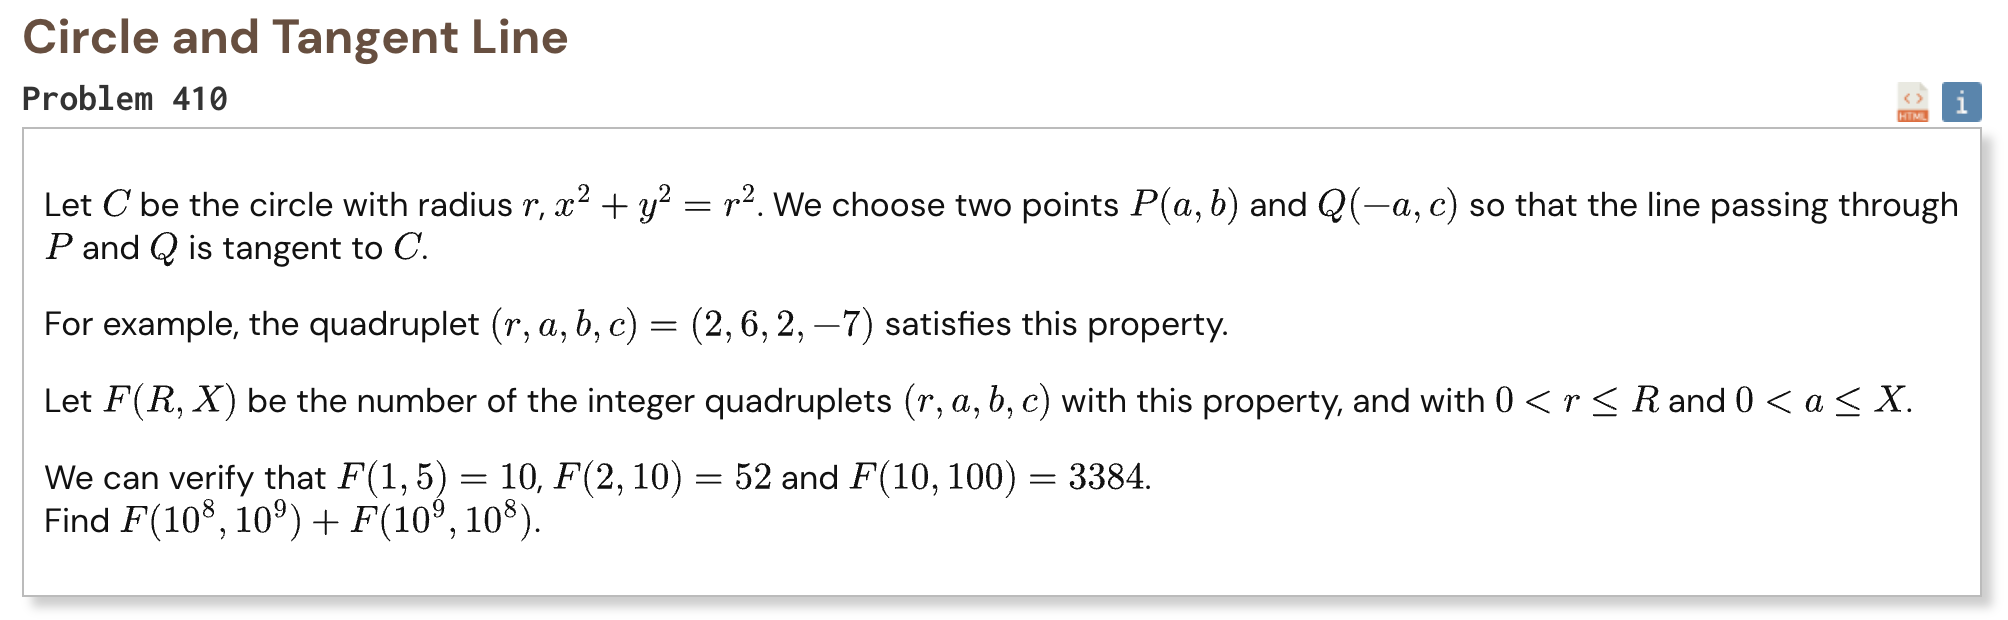

## Initial approach

-   turn the tangent condition into a counting problem based on coprime factor pairs
-   group each factor pair by the product of its two coprime parts
-   count the possible coprime splits using the distinct prime factors
-   handle odd and even products separately because their parity rules differ
-   use a bytearray sieve to store distinct odd prime factor counts compactly
-   count every integer through its odd part and its power of two
-   use symmetry to calculate the large count once and double it

In [1]:
def build_odd_prime_counts(limit):
    counts = bytearray(limit // 2 + 1)

    for prime in range(3, limit + 1, 2):
        if counts[prime // 2] == 0:
            for multiple in range(prime, limit + 1, 2 * prime):
                counts[multiple // 2] += 1

    return counts

def tangent_count(radius_limit, point_limit, prime_counts):
    limit = min(radius_limit, point_limit)
    total = 0

    for odd_part in range(1, limit + 1, 2):
        weight = 1 << prime_counts[odd_part // 2]

        radius_count = radius_limit // odd_part
        point_count = point_limit // odd_part

        total += 2 * weight * radius_count * point_count

        value = 2 * odd_part
        even_weight = 2 * weight

        while value <= limit:
            radius_count = radius_limit // value
            point_count = point_limit // value

            valid_pairs = radius_count * point_count
            valid_pairs += (radius_count & 1) * (point_count & 1)

            total += even_weight * valid_pairs
            value *= 2

    return total

In [2]:
%%time

limit = 10**8
prime_counts = build_odd_prime_counts(limit)

one_direction = tangent_count(10**8, 10**9, prime_counts)
result = 2 * one_direction

print("Result:", result)

Result: 799999783589946560
CPU times: user 39.9 s, sys: 251 ms, total: 40.2 s
Wall time: 40.4 s
